# AutoEIT — Transcription Quality: AssemblyAI (Universal-3.5 Pro + prompting) vs. whisper/speechmatics/AssemblyAI Universal-2 (resegmented, hit recordings)

Follow-up to `analyze_assemblyai_transcription_quality.ipynb`'s Universal-2 run. That session pinned
Universal-2 deliberately (per advisor instruction) to evaluate the actual autoeit.org production
model. This session asks a separate question: how good can AssemblyAI's newest model get when paired
with its Speech-to-Text Prompting feature (an explicit verbatim-transcription instruction, in Spanish,
asking the model to preserve disfluencies/repetitions/false starts by name) rather than relying on
`disfluencies=True` alone?

Run via `src/transcription/transcribe_resegmented_assemblyai_v3.py`, pinned to `speech_models=["universal-3-5-pro"]`
(the API's literal id for what AssemblyAI's docs call "Universal-3.5 Pro" — `"universal-3-pro"`, what
the docs used at the time this was written, is rejected as a deprecated id by a live 400 response).
Same 102-hit-recording restriction as every other resegmented commercial-API source in this harness
(each item is a billed API call). Kept as its own `assemblyai_v3` output/CSV column, separate from
`assemblyai`'s Universal-2 run, so the two configs are comparable side by side rather than one
overwriting the other.

Merged with the existing whisper/speechmatics/assemblyai outputs and the human-rater transcriptions
via `src/postprocessing/build_postprocessed_csv_resegmented.py` (same rank-based item&lt;-&gt;Sentence
alignment and WER/MER/CER scoring as the other resegmented-transcription-quality notebooks). A plain
4-column (stimuli / rater1 / rater2 / assemblyai_v3) reviewable transcript sheet is written separately
by `src/postprocessing/build_assemblyai_v3_excel.py` to `data/postprocessed/assemblyai_v3_transcriptions.xlsx`.

## Metrics: WER, MER, and CER

- **WER (Word Error Rate)** = (S + D + I) / N, where N is the number of words in the reference.
  Unbounded above 1.0 when there are many insertions relative to the reference.
- **MER (Match Error Rate)** = (S + D + I) / (S + D + C + I). Same edit counts as WER, but always in
  [0, 1] — doesn't blow up the way WER can on insertion-heavy output.
- **CER (Character Error Rate)** — the same idea as WER but over characters, more forgiving of
  near-miss spelling/inflection errors and less sensitive to tokenization.

All three are computed after lowercasing and stripping punctuation, against each human rater
separately.


## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["whisper", "speechmatics", "assemblyai", "assemblyai_v3"]
RATERS = ["rater1", "rater2"]
METRICS = ["wer", "mer", "cer"]

hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")

102 hit recordings


## Load per-item scores

One tidy row per (recording, sentence, ASR source, rater), across all hit recordings.

In [3]:
def load_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in ASR_SOURCES:
                for rater in RATERS:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version,
                            "recording": recording_dir.name,
                            "sentence_number": row["sentence_number"],
                            "source": source,
                            "rater": rater,
                            "wer": row[cols[0]],
                            "mer": row[cols[1]],
                            "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


scores = load_scores(hit_recordings)
n_rec = scores["recording"].nunique()
print(f"{len(scores)} scored items, {n_rec} recordings")

23516 scored items, 98 recordings


## Human floor

For context, the inter-rater agreement floor (rater1 vs. rater2, same scoring, see
`analyze_interrater_agreement.ipynb` for the full writeup) over this same 102-recording set, shown
alongside the ASR systems below.

In [4]:
def load_human_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "source": "human",
                    "rater": "rater1_vs_rater2",
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_scores = load_human_scores(hit_recordings)
scores_with_human = pd.concat([scores, human_scores], ignore_index=True)
print(f"human floor: {len(human_scores)} scored sentences")

human floor: 2940 scored sentences


In [5]:
source_colors = {
    "whisper": "#4C72B0",
    "speechmatics": "#CCB974",
    "assemblyai": "#DA8BC3",
    "assemblyai_v3": "#64B5CD",
    "human": "#777777",
}
DISPLAY_SOURCES = ASR_SOURCES + ["human"]


def summarize(scores: pd.DataFrame, order: list[str] = ASR_SOURCES) -> pd.DataFrame:
    mean_tbl = scores.groupby("source")[METRICS].mean().round(4).reindex(order)
    median_tbl = scores.groupby("source")[METRICS].median().round(4).reindex(order)
    pct_perfect = scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(order)
    out = mean_tbl.add_suffix("_mean").join(median_tbl.add_suffix("_median"))
    out["wer_pct_perfect"] = pct_perfect
    return out


def plot_metrics(scores: pd.DataFrame, title: str, save_path: str, order: list[str] = ASR_SOURCES) -> None:
    summary = scores.groupby("source")[METRICS].mean().reindex(order)
    x = np.arange(len(order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, metric in enumerate(METRICS):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, summary[metric], width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

## Hit recordings (n=102, both raters), all 4 ASR systems vs. human floor

In [6]:
summarize(scores_with_human, order=DISPLAY_SOURCES)

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
speechmatics,0.2225,0.2066,0.1305,0.1429,0.1250,0.0455,0.364
assemblyai,0.2902,0.2787,0.1875,0.1429,0.1429,0.0536,0.350
assemblyai_v3,0.2363,0.2115,0.1302,0.1250,0.1250,0.0435,0.370
human,0.1608,0.1501,0.0763,0.1111,0.1111,0.0250,0.429


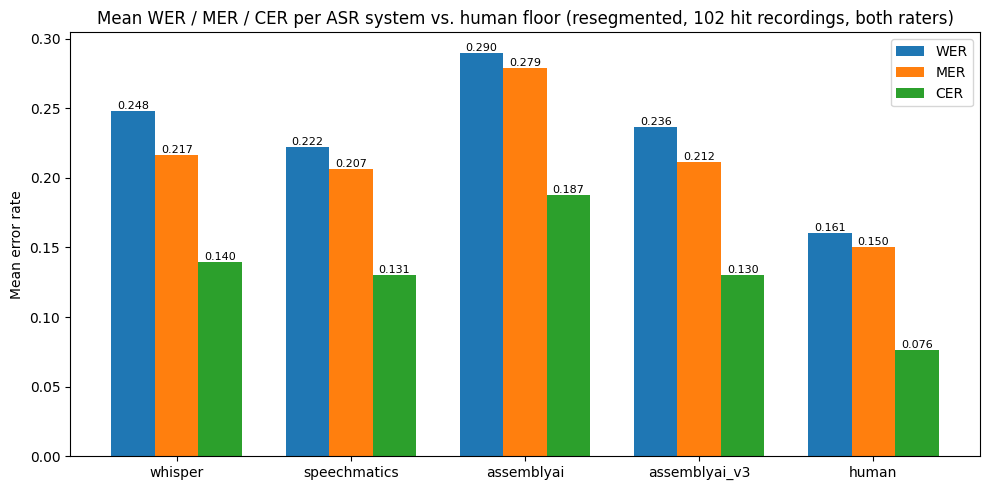

In [7]:
plot_metrics(
    scores_with_human,
    "Mean WER / MER / CER per ASR system vs. human floor (resegmented, 102 hit recordings, both raters)",
    "../plots/assemblyai_v3_transcription_quality_metrics.png",
    order=DISPLAY_SOURCES,
)

## Universal-3.5 Pro + prompting vs. the previous best (speechmatics) and vs. Universal-2

The two questions this run was meant to answer: does AssemblyAI's newest model, paired with
disfluency-aware prompting, close the gap to speechmatics (the current best in the harness)? And does
it actually improve on AssemblyAI's own Universal-2 result, or does the deprecated-model-id snag
during the run suggest the newer model isn't a clean drop-in win either?

In [8]:
summarize(scores, order=["speechmatics", "assemblyai", "assemblyai_v3"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
speechmatics,0.2225,0.2066,0.1305,0.1429,0.1250,0.0455,0.364
assemblyai,0.2902,0.2787,0.1875,0.1429,0.1429,0.0536,0.350
assemblyai_v3,0.2363,0.2115,0.1302,0.1250,0.1250,0.0435,0.370


## AssemblyAI Universal-3.5 Pro vs. human floor

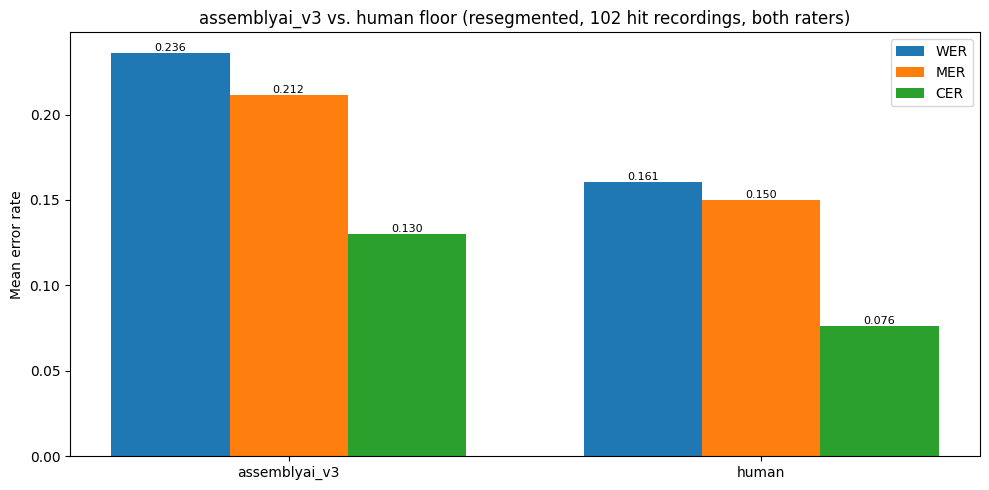

In [9]:
pair = scores_with_human[scores_with_human["source"].isin(["assemblyai_v3", "human"])]
plot_metrics(
    pair,
    "assemblyai_v3 vs. human floor (resegmented, 102 hit recordings, both raters)",
    "../plots/assemblyai_v3_vs_human_metrics.png",
    order=["assemblyai_v3", "human"],
)